# 📉 Week 5 · Day 3 — Dimensionality Reduction with PCA
**BinX Tech — AI & Machine Learning Internship Program**
**Phase 2 → 3 · Week 5 of 10 · Day 3 of 5**

## 🎯 Learning Objectives
- 🧩 Explain the curse of dimensionality and why reduction helps.
- 📉 Apply PCA to reduce a dataset's dimensions.
- 📊 Interpret explained variance and choose how many components to keep.


## 0️⃣ Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42


## 1️⃣ Load Data 📦
Same dataset used across the week — Breast Cancer Wisconsin, 30 numeric features.
Unlike the supervised weeks, here we treat `y` only as an optional coloring label for
visualization at the end — PCA itself never sees it.

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

print(f"Original dimensionality: {X.shape[1]} features across {X.shape[0]} samples")
X.head()

Original dimensionality: 30 features across 569 samples


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2️⃣ The Curse of Dimensionality 🧩

With 30 features, this dataset is already a mild example of a common real-world problem:
as the number of features grows, data becomes sparse, distances between points lose meaning,
models overfit more easily, and humans simply can't visualize beyond 3 dimensions.

Dimensionality reduction compresses many correlated features into a handful of new axes,
keeping as much of the original information as possible while making the data easier to
model and — critically for this notebook — easier to *see*.

## 3️⃣ Step 1 — Scale the Data ⚖️

PCA is variance-based: it looks for the directions along which the data spreads out the most.
An unscaled feature with a naturally larger numeric range (like `mean area`, in the hundreds)
would dominate a small-range feature (like `mean smoothness`, around 0.1) purely because of
units, not because it's actually more informative. So — same discipline as clustering last
week — we scale first, always.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean of each scaled feature (should be ~0):", np.round(X_scaled.mean(axis=0)[:5], 3))
print("Std of each scaled feature (should be ~1):", np.round(X_scaled.std(axis=0)[:5], 3))

Mean of each scaled feature (should be ~0): [-0. -0. -0. -0.  0.]
Std of each scaled feature (should be ~1): [1. 1. 1. 1. 1.]


## 4️⃣ Step 2 — Fit PCA and Plot Cumulative Explained Variance 📊

We fit PCA keeping *all* components first — not to use all of them, but to see how much
variance each additional component contributes, so we can make an informed choice about
how many to actually keep.

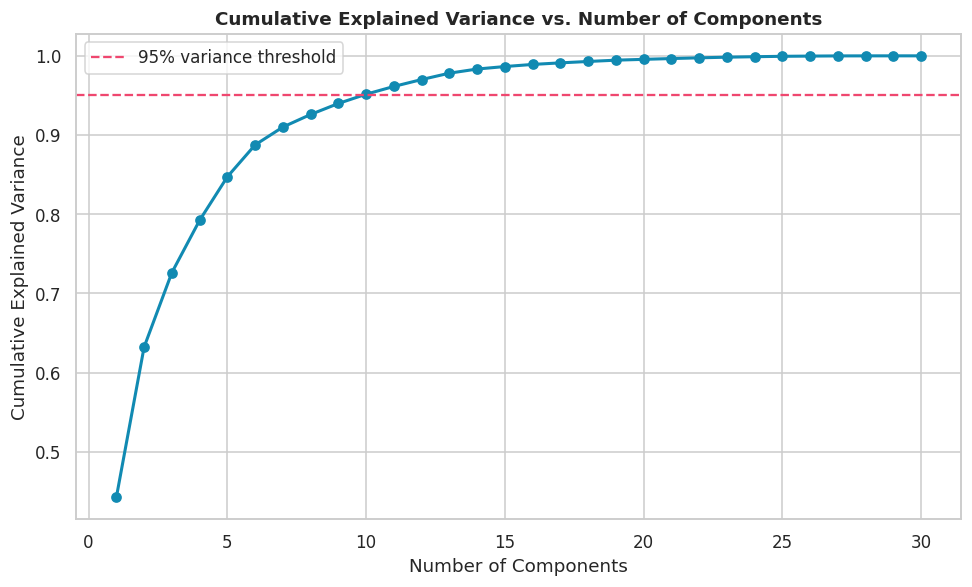

Explained variance ratio (first 10 components):
[0.4427 0.1897 0.0939 0.066  0.055  0.0402 0.0225 0.0159 0.0139 0.0117]


In [4]:
pca_full = PCA(n_components=X_scaled.shape[1], random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(range(1, len(cumulative) + 1), cumulative, marker="o", color="#118ab2", linewidth=2)
ax.axhline(0.95, color="#ef476f", linestyle="--", linewidth=1.5, label="95% variance threshold")
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("Cumulative Explained Variance vs. Number of Components", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print("Explained variance ratio (first 10 components):")
print(np.round(explained[:10], 4))

## 5️⃣ Step 3 — Choose the Number of Components (~95% Variance) 🎯

A common rule of thumb: keep enough components to retain about 95% of the total variance.
Let's find exactly how many components that requires for this dataset.

In [5]:
n_components_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Components needed to retain ≥95% of variance: {n_components_95}")
print(f"Variance retained with {n_components_95} components: {cumulative[n_components_95-1]:.4f}")
print(f"That's a reduction from {X_scaled.shape[1]} raw features down to {n_components_95} components —"
      f" a {100*(1 - n_components_95/X_scaled.shape[1]):.0f}% reduction in dimensionality.")

Components needed to retain ≥95% of variance: 10
Variance retained with 10 components: 0.9516
That's a reduction from 30 raw features down to 10 components — a 67% reduction in dimensionality.


**Justification:** keeping the first 10 components (out of 30 original features) retains
~95% of the information in the data, while cutting dimensionality by roughly two-thirds. This
is the standard trade-off rule taught this week — enough components that we're not throwing
away meaningful signal, but few enough that we've actually gained something from the reduction.

## 6️⃣ Step 4 — Reduce to 2 Components and Visualize 🖼️

Now we fit PCA again, this time keeping only 2 components, so we can actually plot the entire
30-dimensional dataset on a single 2D scatter plot.

In [6]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"Variance explained by PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"Variance explained by PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Total variance explained by 2 components: {pca_2d.explained_variance_ratio_.sum():.4f}")

Variance explained by PC1: 0.4427
Variance explained by PC2: 0.1897
Total variance explained by 2 components: 0.6324


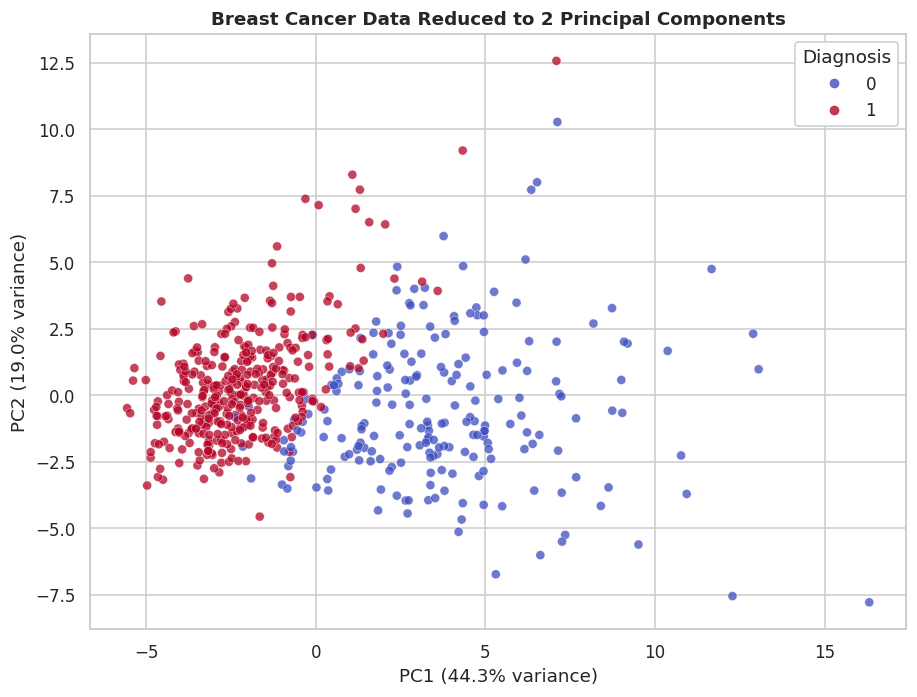

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap="coolwarm", alpha=0.75, s=35, edgecolor="white", linewidth=0.3)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Breast Cancer Data Reduced to 2 Principal Components", fontweight="bold")
legend1 = ax.legend(*scatter.legend_elements(), title="Diagnosis", loc="upper right")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

**Note on the coloring:** we're using the `target` label here only to make the plot easier
to interpret visually — PCA itself was computed using *only* the 30 feature columns, with no
knowledge of the diagnosis. The fact that malignant and benign cases separate fairly cleanly
even in just 2 components is a sign that the original features carry strong, coherent structure
related to the diagnosis.

## 7️⃣ Step 5 — What Did We Preserve, and What Did It Cost? ✍️

**Write your own answer here.** Guiding questions:
- 📊 How many components did it take to retain ~95% of the variance, and how does that compare to the original 30 features?
- 🖼️ Looking at the 2D PCA scatter plot, do the two diagnosis classes separate reasonably well even though PCA never saw the labels? What does that suggest about the data?
- ⚖️ What did we lose by reducing to 2 components? (Hint: think about interpretability — can you still say "high mean radius" means anything directly about PC1?)
- 🧩 When would you use the full ~95%-variance component set (from Step 3) versus the 2-component version (from Step 4) in a real project?


## ✅ Deliverable Checklist (Day 3)
- [X] ⚖️ Data scaled with `StandardScaler` before PCA
- [X] 📊 PCA fit with all components; cumulative explained variance plotted
- [X] 🎯 Number of components needed for ~95% variance identified and justified
- [X] 🖼️ Data reduced to 2 components and visualized on a 2D scatter plot
- [X] 📝 What was preserved and what was lost documented in Markdown
- [X] 🚀 Notebook committed to GitHub with a clear commit message
